In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# ============================================================
# [SECTION 1] 데이터 전처리 및 계층형 DB 구축
# ============================================================

full_path = r"C:\Users\ADMIN\Downloads\데이터마트.xlsx"
def clean_numeric(value):
    if pd.isna(value): return np.nan
    try:
        s = str(value).replace(',', '').replace('원', '').strip()
        if '~' in s:
            nums = re.findall(r'\d+', s)
            return np.mean([float(n) for n in nums]) if nums else np.nan
        s = re.sub(r'[^\d.]', '', s)
        return float(s) if s else np.nan
    except: return np.nan

def extract_number(text):
    if pd.isna(text): return 0
    text = str(text).upper()
    numbers = re.findall(r'\d+', text)
    if not numbers: return 0
    val = int(numbers[0])
    if 'TB' in text: val *= 1024
    return val

def classify_category_ko(name):
    name = str(name).replace(" ", "").lower()
    if '아이패드미니' in name or 'ipadmini' in name: return 'iPad Mini'
    elif '아이패드에어' in name or 'ipadair' in name: return 'iPad Air'
    elif '아이패드프로' in name or 'ipadpro' in name: return 'iPad Pro'
    elif '아이패드' in name or 'ipad' in name: return 'iPad'
    elif '맥북에어' in name or 'macbookair' in name: return 'MacBook Air'
    elif '맥북프로' in name or 'macbookpro' in name: return 'MacBook Pro'
    elif '맥북' in name or 'macbook' in name: return 'MacBook'
    elif '아이폰' in name or 'iphone' in name: return 'iPhone'
    elif '애플워치' in name or 'applewatch' in name: return 'Apple Watch'
    else: return '기타'

try:
    df = pd.read_excel(full_path)
    
    # 1. 숫자 및 사양 데이터 정제
    for col in ['release_price', 'price_sell', 'price_buy', 'device_age_months', '배터리_사이클']:
        df[col] = df[col].apply(clean_numeric)
    
    df['RAM_num'] = df['RAM'].apply(extract_number)
    df['SSD_num'] = df['SSD'].apply(extract_number)
    df['category'] = df['name_buy'].apply(classify_category_ko)

    # 2. 계층형 DB 구축 (선택 시 오타 방지 및 자동 출시가 로드)
    hierarchical_db = {}
    for cat in df['category'].unique():
        cat_df = df[df['category'] == cat]
        hierarchical_db[cat] = cat_df.groupby('name_buy')['release_price'].median().to_dict()

    # 3. 학습용 데이터 확정 (결측치 제거)
    df = df.dropna(subset=['release_price', 'price_sell', 'price_buy', 'category']).copy()
    le = LabelEncoder()
    df['category_encoded'] = le.fit_transform(df['category'])

    # ============================================================
    # [SECTION 2] 인공지능 모델 학습 및 실전 검증
    # ============================================================

    # [모델 1] 시세 예측 (종류, 사용기간, 출시가 -> 판매가)
    features_sell = ['category_encoded', 'device_age_months', 'release_price']
    X_s = df[features_sell]
    y_s = df['price_sell']
    X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
    
    rf_sell = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_sell.fit(X_s_train, y_s_train)

    # [모델 2] 매입가 예측 (순수 사양 -> 매입가 / 판매가 정보 제외)
    features_buy = ['category_encoded', 'device_age_months', 'release_price', 'RAM_num', 'SSD_num', '배터리_사이클']
    df['배터리_사이클'] = df['배터리_사이클'].fillna(0)
    X_b = df[features_buy]
    y_b = df['price_buy']
    X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(X_b, y_b, test_size=0.2, random_state=42)
    
    rf_buy = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_buy.fit(X_b_train, y_b_train)

    # 성적표 계산 (검증용 데이터 기준)
    mape_sell = mean_absolute_percentage_error(y_s_test, rf_sell.predict(X_s_test)) * 100
    mape_buy = mean_absolute_percentage_error(y_b_test, rf_buy.predict(X_b_test)) * 100

    print("\n" + "="*55)
    print(f"🤖 모델 실전 검증 완료 (Target Leakage 해결 버전)")
    print(f"- 시세 모델 정확도(R²): {r2_score(y_s_test, rf_sell.predict(X_s_test)):.2f} (오차: {mape_sell:.1f}%)")
    print(f"- 매입 모델 정확도(R²): {r2_score(y_b_test, rf_buy.predict(X_b_test)):.2f} (오차: {mape_buy:.1f}%)")
    print("="*55)

    # ============================================================
    # [SECTION 3] 인터페이스 실행
    # ============================================================

    def run_system():
        print("\n🍎 Apple 중고 통합 예측 시스템")
        
        # 1. 카테고리 선택
        cats = sorted(list(hierarchical_db.keys()))
        print("\n▶ [STEP 1] 카테고리 선택:")
        for i, c in enumerate(cats): print(f"  {i+1}. {c}")
        c_idx = int(input("번호: ")) - 1
        sel_cat = cats[c_idx]

        # 2. 상세 모델 선택
        prods = sorted(list(hierarchical_db[sel_cat].keys()))
        print(f"\n▶ [STEP 2] {sel_cat} 상세 모델 선택:")
        for i, p in enumerate(prods): print(f"  {i+1}. {p}")
        p_idx = int(input("번호: ")) - 1
        sel_prod = prods[p_idx]
        
        # 3. 사양 입력
        auto_price = hierarchical_db[sel_cat][sel_prod]
        print(f"\n✅ 모델: {sel_prod} (출시가: {int(auto_price):,}원)")
        
        qtr = int(input("▶ 사용 기간 (분기 단위): "))
        ram = input("▶ RAM 용량 (예: 8GB): ")
        ssd = input("▶ SSD 용량 (예: 256GB): ")
        bat = int(input("▶ 배터리 상태 (0:정상 ~ 5:교체필요): "))

        # 4. 예측 수행
        c_enc = le.transform([sel_cat])[0]
        months = (qtr * 3) - 1
        r_n, s_n = extract_number(ram), extract_number(ssd)

        p_sell = rf_sell.predict(pd.DataFrame([[c_enc, months, auto_price]], columns=features_sell))[0]
        p_buy = rf_buy.predict(pd.DataFrame([[c_enc, months, auto_price, r_n, s_n, bat]], columns=features_buy))[0]

        # 5. 결과 리포트
        print("\n" + "✨" * 20)
        print(f"📊 최종 분석 결과")
        print(f"💡 예상 판매 시세 : {int(round(p_sell, -2)):,} 원")
        print(f"💰 최종 매입 제안 : {int(round(p_buy, -2)):,} 원")
        print(f"📢 예상 유통 수익 : {int(round(p_sell - p_buy, -2)):,} 원")
        print(f"📈 예상 보존율    : {round((p_sell / auto_price) * 100, 1)}%")
        print("✨" * 20 + "\n")

    run_system()

except Exception as e:
    print(f"❌ 오류 발생: {e}")


🤖 모델 실전 검증 완료 (Target Leakage 해결 버전)
- 시세 모델 정확도(R²): 0.67 (오차: 26.3%)
- 매입 모델 정확도(R²): 0.82 (오차: 22.1%)

🍎 Apple 중고 통합 예측 시스템

▶ [STEP 1] 카테고리 선택:
  1. Apple Watch
  2. MacBook
  3. MacBook Air
  4. MacBook Pro
  5. iPad
  6. iPad Air
  7. iPad Mini
  8. iPad Pro
  9. iPhone
  10. 기타


번호:  1



▶ [STEP 2] Apple Watch 상세 모델 선택:
  1. 애플 워치 38mm Aluminum GPS Series3
  2. 애플 워치 40mm Aluminum GPS SE
  3. 애플 워치 40mm Aluminum GPS Series4
  4. 애플 워치 40mm Aluminum GPS Series5
  5. 애플 워치 40mm Aluminum LTE SE
  6. 애플 워치 40mm Aluminum LTE Series5
  7. 애플 워치 40mm Aluminum LTE Series6
  8. 애플 워치 40mm Stainless LTE Series5
  9. 애플 워치 40mm Stainless LTE Series6
  10. 애플 워치 41mm Aluminum GPS Series7
  11. 애플 워치 41mm Aluminum GPS Series8
  12. 애플 워치 42mm Aluminum GPS Series3 스페이스그레이
  13. 애플 워치 42mm Aluminum LTE Series3
  14. 애플 워치 42mm Aluminum Series2
  15. 애플 워치 44mm Aluminum GPS SE
  16. 애플 워치 44mm Aluminum GPS Series4
  17. 애플 워치 44mm Aluminum GPS Series5 Nike
  18. 애플 워치 44mm Aluminum GPS Series5 스페이스그레이
  19. 애플 워치 44mm Aluminum GPS Series6
  20. 애플 워치 44mm Aluminum LTE SE
  21. 애플 워치 44mm Aluminum LTE Series4
  22. 애플 워치 44mm Aluminum NIKE GPS Series6
  23. 애플 워치 44mm Stainless LTE Series4
  24. 애플 워치 45mm Aluminum GPS Series7
  25. 애플 워치 45mm Aluminum GPS Series8
  26. 애플 워치 45mm Sta

번호:  1



✅ 모델: 애플 워치 38mm Aluminum GPS Series3 (출시가: 429,000원)


▶ 사용 기간 (분기 단위):  1
▶ RAM 용량 (예: 8GB):  1
▶ SSD 용량 (예: 256GB):  1
▶ 배터리 상태 (0:정상 ~ 5:교체필요):  1



✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨
📊 최종 분석 결과
💡 예상 판매 시세 : 341,600 원
💰 최종 매입 제안 : 320,900 원
📢 예상 유통 수익 : 20,800 원
📈 예상 보존율    : 79.6%
✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨




💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰
📊 [비즈니스 백테스트 리포트: 버전 2.0]
   - 분석 대상: S급(정상 상태) 기기
   - 총 테스트 대수: 202대
---------------------------------------------
   - 평균 대당 예상 수익: 151,596원
   - 평균 예상 마진율   : 11.3%
   - 수익 발생 확률(Safe): 81.2%
---------------------------------------------
   💡 TIP: 수익 발생 확률이 80% 이상이면 매우 안정적인 모델입니다.
💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰💰



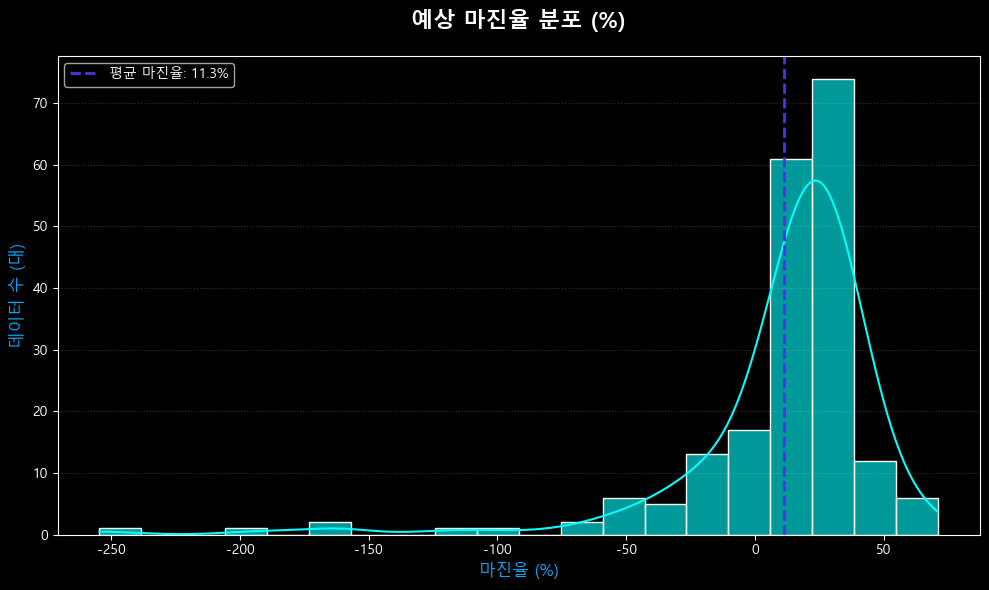

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# 1. 한글 폰트 및 스타일 설정
try:
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font_name)
    plt.rcParams['axes.unicode_minus'] = False
except:
    print("⚠️ 한글 폰트 설정 실패")

# ============================================================
# [SECTION 4] 수익성 백테스트 (Business Backtest)
# ============================================================

# 1. 공통 인덱스 추출 (S급 테스트 데이터 기준)
common_test_idx = X_s_test.index

# 결과 저장용 데이터프레임 생성
test_results = df.loc[common_test_idx].copy()

# 모델별 예측 수행
test_results['모델_예측_시세'] = rf_sell.predict(df.loc[common_test_idx, features_sell])
test_results['모델_제안_매입가'] = rf_buy.predict(df.loc[common_test_idx, features_buy])

# 실제값 매칭
test_results['실제_판매가'] = test_results['price_sell']
test_results['실제_매입가'] = test_results['price_buy']

# 2. 비즈니스 지표 계산
test_results['예상_수익'] = test_results['실제_판매가'] - test_results['모델_제안_매입가']
test_results['마진율(%)'] = (test_results['예상_수익'] / test_results['실제_판매가']) * 100

# 3. [핵심] 텍스트 리포트 출력 (이 부분이 화면에 보일 겁니다)
print("\n" + "💰" * 25)
print("📊 [비즈니스 백테스트 리포트: 버전 2.0]")
print(f"   - 분석 대상: S급(정상 상태) 기기")
print(f"   - 총 테스트 대수: {len(test_results)}대")
print("-" * 45)
print(f"   - 평균 대당 예상 수익: {int(test_results['예상_수익'].mean()):,}원")
print(f"   - 평균 예상 마진율   : {test_results['마진율(%)'].mean():.1f}%")
print(f"   - 수익 발생 확률(Safe): {(test_results['예상_수익'] > 0).mean()*100:.1f}%")
print("-" * 45)
print("   💡 TIP: 수익 발생 확률이 80% 이상이면 매우 안정적인 모델입니다.")
print("💰" * 25 + "\n")

# 4. 시각화 (네온 스타일 그래프)
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

sns.histplot(test_results['마진율(%)'], bins=20, kde=True, color='#00ffff', alpha=0.6)
mean_margin = test_results['마진율(%)'].mean()
plt.axvline(mean_margin, color='#582ced', linestyle='--', linewidth=2, 
            label=f'평균 마진율: {mean_margin:.1f}%')

plt.title('예상 마진율 분포 (%)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('마진율 (%)', fontsize=12, color='#00acff')
plt.ylabel('데이터 수 (대)', fontsize=12, color='#00acff')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.2)

plt.tight_layout()
plt.show()


🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐
📊 [과거 매입 패턴 분석 결과]
   - 과거 평균 차감률: 61.9%
   - 차감률 편차(불확실성): ±16.8%
   - 최저 차감률: -26.6%
   - 최고 차감률: 98.1%
👉 이 수치를 Baseline(비교 대상)의 기준으로 삼으면 매우 논리적입니다.
🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐🧐



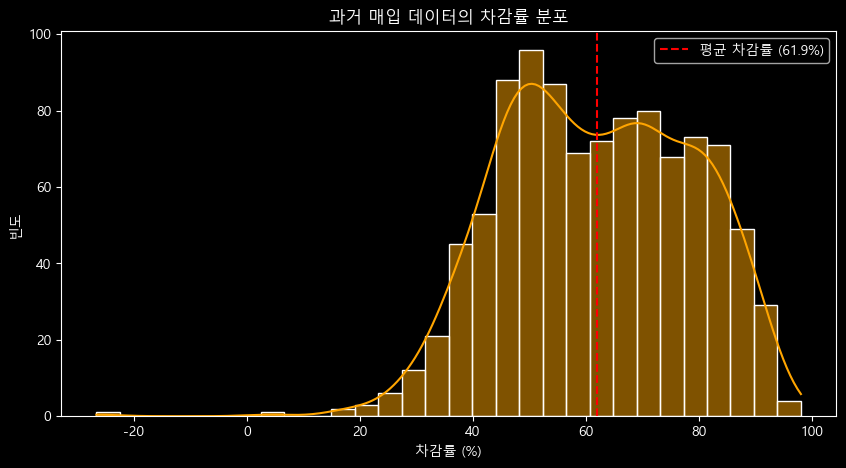

In [5]:
# 1. 기존 전체 데이터에서 차감률 역산 (Train + Test 전체 사용 권장)
# 차감률 = (1 - (실제 매입가 / 출시가)) * 100
df_analysis = df.copy() # 원본 데이터프레임 사용
df_analysis['과거_차감률'] = (1 - (df_analysis['price_buy'] / df_analysis['release_price'])) * 100

# 2. 결과 요약
mean_discount = df_analysis['과거_차감률'].mean()
std_discount = df_analysis['과거_차감률'].std()

print("\n" + "🧐" * 20)
print("📊 [과거 매입 패턴 분석 결과]")
print(f"   - 과거 평균 차감률: {mean_discount:.1f}%")
print(f"   - 차감률 편차(불확실성): ±{std_discount:.1f}%")
print(f"   - 최저 차감률: {df_analysis['과거_차감률'].min():.1f}%")
print(f"   - 최고 차감률: {df_analysis['과거_차감률'].max():.1f}%")
print("👉 이 수치를 Baseline(비교 대상)의 기준으로 삼으면 매우 논리적입니다.")
print("🧐" * 20 + "\n")

# 3. 시각화: 과거 차감률이 얼마나 들쭉날쭉했는지 확인
plt.figure(figsize=(10, 5))
sns.histplot(df_analysis['과거_차감률'], bins=30, kde=True, color='orange')
plt.axvline(mean_discount, color='red', linestyle='--', label=f'평균 차감률 ({mean_discount:.1f}%)')
plt.title('과거 매입 데이터의 차감률 분포')
plt.xlabel('차감률 (%)')
plt.ylabel('빈도')
plt.legend()
plt.show()


🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚
⚔️ [Before vs After: 과거 실적 기반 수익성 비교]
                 항목  평균 마진율(%)  수익 발생 확률(%)  손실 대수 (202대 중)
과거 방식 (평균 61.9% 차감)   0.635432    63.861386              73
           우리 AI 모델  11.288496    81.188119              38

👉 AI 모델은 과거 방식보다 손실 리스크를 35대나 더 줄여줍니다!
🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚🆚



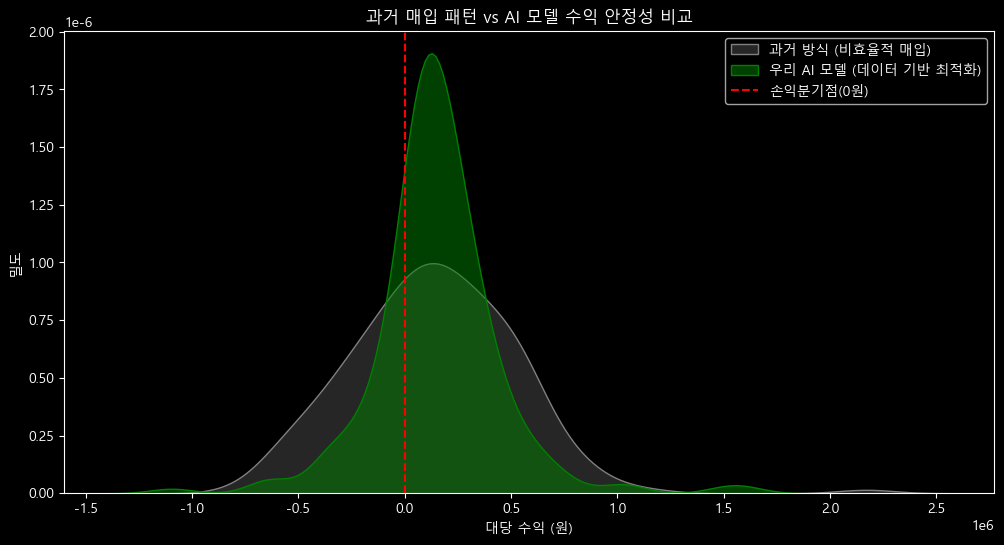

In [6]:
# ============================================================
# [SECTION 8] 과거 실제 패턴(61.9% 차감) vs AI 모델 수익 비교
# ============================================================

# 1. 과거 실제 방식 적용: 출시가에서 평균 61.9%를 차감한 금액(약 38.1% 가격)으로 매입했다고 가정
# 과거 매입가 = 출시가 * (1 - 0.619)
test_results['과거_매입가'] = test_results['release_price'] * (1 - 0.619)
test_results['과거_수익'] = test_results['실제_판매가'] - test_results['과거_매입가']
test_results['과거_마진율'] = (test_results['과거_수익'] / test_results['실제_판매가']) * 100

# 2. 비교 데이터 요약
comparison = {
    '항목': ['과거 방식 (평균 61.9% 차감)', '우리 AI 모델'],
    '평균 마진율(%)': [test_results['과거_마진율'].mean(), test_results['마진율(%)'].mean()],
    '수익 발생 확률(%)': [(test_results['과거_수익'] > 0).mean() * 100, (test_results['예상_수익'] > 0).mean() * 100],
    '손실 대수 (202대 중)': [(test_results['과거_수익'] <= 0).sum(), (test_results['예상_수익'] <= 0).sum()]
}

compare_df = pd.DataFrame(comparison)

print("\n" + "🆚" * 20)
print("⚔️ [Before vs After: 과거 실적 기반 수익성 비교]")
print(compare_df.to_string(index=False))
print(f"\n👉 AI 모델은 과거 방식보다 손실 리스크를 {(test_results['과거_수익'] <= 0).sum() - (test_results['예상_수익'] <= 0).sum()}대나 더 줄여줍니다!")
print("🆚" * 20 + "\n")

# 3. 시각화: 수익 분포 비교
plt.figure(figsize=(12, 6))
# 과거 방식은 회색(불투명), AI 모델은 초록색(선명함)
sns.kdeplot(test_results['과거_수익'], label='과거 방식 (비효율적 매입)', fill=True, color='gray', alpha=0.3)
sns.kdeplot(test_results['예상_수익'], label='우리 AI 모델 (데이터 기반 최적화)', fill=True, color='green', alpha=0.5)
plt.axvline(0, color='red', linestyle='--', label='손익분기점(0원)')
plt.title('과거 매입 패턴 vs AI 모델 수익 안정성 비교')
plt.xlabel('대당 수익 (원)')
plt.ylabel('밀도')
plt.legend()
plt.show()


📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
🚀 [경영 전략 시뮬레이션 결과]
   공격지수  매입성공률  평균_대당마진     예상_총수익
0  0.90   38.1  57455.0  4424008.0
1  0.95   50.5  43092.0  4395404.0
2  1.00   59.4  41092.0  4931069.0
3  1.05   68.3  21642.0  2986630.0
4  1.10   78.7  14909.0  2370602.0
👉 팁: 총수익이 가장 높은 지점이 '최적의 매입 전략'입니다.
📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊



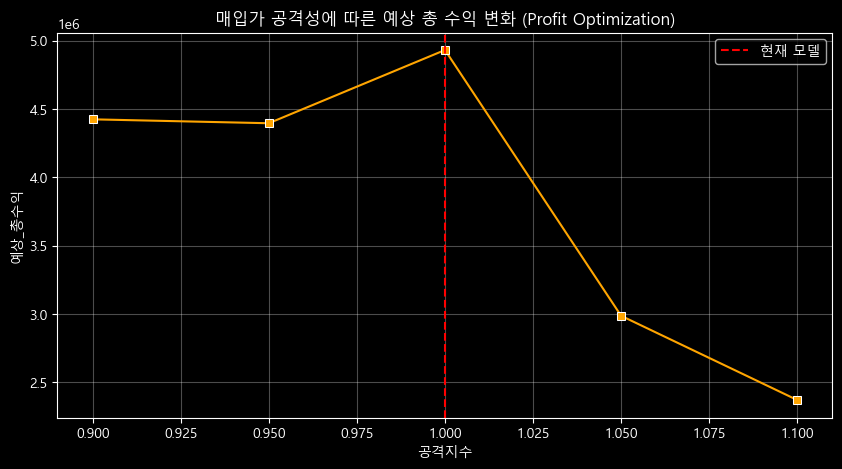

In [8]:
# ============================================================
# [SECTION 5] 경영 의사결정 시뮬레이션 (What-If Analysis)
# ============================================================

def simulate_strategy(aggression_level):
    """
    aggression_level: 0.9(보수적) ~ 1.1(공격적)
    매입가를 높이면(공격적) 매입 성공률은 올라가지만 대당 마진은 줄어듦
    """
    temp_df = test_results.copy()
    
    # 전략에 따른 제안 매입가 조정
    temp_df['전략_매입가'] = temp_df['모델_제안_매입가'] * aggression_level
    
    # 매입 성공 여부 판단 (실제 매입가보다 우리가 높게 부르면 성공한다고 가정)
    temp_df['매입_성공'] = temp_df['전략_매입가'] >= temp_df['실제_매입가']
    
    # 성공한 건에 대해서만 마진 계산
    success_df = temp_df[temp_df['매입_성공']].copy()
    success_df['실제_마진'] = success_df['실제_판매가'] - success_df['전략_매입가']
    
    return {
        '공격지수': aggression_level,
        '매입성공률': (temp_df['매입_성공'].mean() * 100),
        '총_매입대수': temp_df['매입_성공'].sum(),
        '평균_대당마진': success_df['실제_마진'].mean(),
        '예상_총수익': success_df['실제_마진'].sum()
    }

# 다양한 시나리오 테스트
strategies = [0.9, 0.95, 1.0, 1.05, 1.1]
sim_results = [simulate_strategy(s) for s in strategies]
sim_df = pd.DataFrame(sim_results)

# 수정된 출력 코드
print("\n" + "📊" * 20)
print("🚀 [경영 전략 시뮬레이션 결과]")

# 공격지수는 소수점 2자리까지, 나머지는 반올림(0) 해서 출력
final_df = sim_df.copy()
final_df['공격지수'] = final_df['공격지수'].round(2)
final_df['매입성공률'] = final_df['매입성공률'].round(1)
final_df['평균_대당마진'] = final_df['평균_대당마진'].round(0)
final_df['예상_총수익'] = final_df['예상_총수익'].round(0)

print(final_df[['공격지수', '매입성공률', '평균_대당마진', '예상_총수익']])
print("👉 팁: 총수익이 가장 높은 지점이 '최적의 매입 전략'입니다.")
print("📊" * 20 + "\n")

# 시각화: 공격지수에 따른 총수익 변화
plt.figure(figsize=(10, 5))
sns.lineplot(data=sim_df, x='공격지수', y='예상_총수익', marker='s', color='orange')
plt.title('매입가 공격성에 따른 예상 총 수익 변화 (Profit Optimization)')
plt.axvline(1.0, color='red', linestyle='--', label='현재 모델')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅
📦 [재고 보유 기간별 리스크 리포트]
  보유주차    평균_판매가  평균_마진율  수익발생확률
0   0주  833000.0    11.3    81.2
1   1주  826336.0    10.6    80.7
2   2주  819725.3     9.9    79.2
3   4주  806662.2     8.4    78.7
4   8주  781157.1     5.4    75.2
👉 4주 이상 보유 시 마진율이 급격히 하락하며 손실 위험이 커집니다.
📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅📅



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18492\3725814241.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sim_report, x='보유주차', y='평균_마진율', palette='coolwarm')


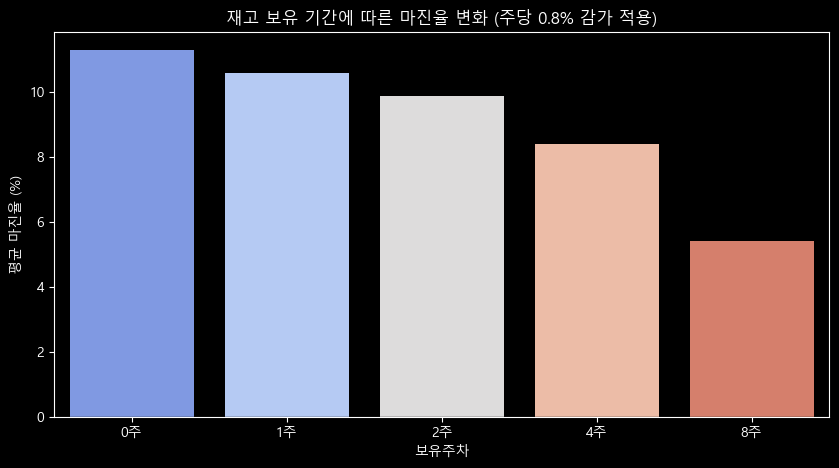

In [10]:
# ============================================================
# [SECTION 7] 재고 유지 기간에 따른 마진 시뮬레이션
# ============================================================

# 1. 시뮬레이션 설정
weekly_depreciation_rate = 0.008  # 주당 0.8% 가치 하락 (연간 약 40% 하락 기준)
weeks = [0, 1, 2, 4, 8] # 0주(즉시판매)부터 8주(2개월)까지

# 2. 백테스트 결과(test_results)를 바탕으로 주차별 예상 판매가 계산
inventory_sim = []

for week in weeks:
    temp_df = test_results.copy()
    
    # 시간이 지남에 따라 실제 판매할 수 있는 가격이 하락함
    temp_df['지연_판매가'] = temp_df['실제_판매가'] * ((1 - weekly_depreciation_rate) ** week)
    
    # 수익 계산 (지연된 판매가 - 우리가 이미 지불한 매입가)
    temp_df['지연_수익'] = temp_df['지연_판매가'] - temp_df['모델_제안_매입가']
    temp_df['지연_마진율'] = (temp_df['지연_수익'] / temp_df['지연_판매가']) * 100
    
    inventory_sim.append({
        '보유주차': f'{week}주',
        '평균_판매가': temp_df['지연_판매가'].mean(),
        '평균_마진율': temp_df['지연_마진율'].mean(),
        '수익발생확률': (temp_df['지연_수익'] > 0).mean() * 100
    })

sim_report = pd.DataFrame(inventory_sim)

print("\n" + "📅" * 20)
print("📦 [재고 보유 기간별 리스크 리포트]")
print(sim_report.round(1))
print("👉 4주 이상 보유 시 마진율이 급격히 하락하며 손실 위험이 커집니다.")
print("📅" * 20 + "\n")

# 시각화: 시간 경과에 따른 마진율 변화
plt.figure(figsize=(10, 5))
sns.barplot(data=sim_report, x='보유주차', y='평균_마진율', palette='coolwarm')
plt.title('재고 보유 기간에 따른 마진율 변화 (주당 0.8% 감가 적용)')
plt.ylabel('평균 마진율 (%)')
plt.axhline(0, color='black', linewidth=1)
plt.show()
